<a href="https://colab.research.google.com/github/jmmarinr/ComputationalMethods/blob/master/EDO/RK4_SolveIvp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
#@title Librerias
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Método de Runge-Kutta de 4º orden

---

**Prof. Juan Marcos Marín Ramírez**

---


El método de Runge-Kutta de 4º orden (RK4) es una técnica numérica para resolver ecuaciones diferenciales ordinarias (EDOs) de la forma:

$$\frac{dy}{dx} = f(x, y), \quad y(x_0) = y_0$$

Este método proporciona una aproximación de alta precisión comparado con métodos más simples como Euler, utilizando una combinación ponderada de evaluaciones de la función en diferentes puntos dentro del intervalo de integración.

### Fórmula general

Para avanzar desde un punto $(x_n, y_n)$ al siguiente punto $(x_{n+1}, y_{n+1})$ con un paso $h$, el método RK4 utiliza:

$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

donde:

$$k_1 = f(x_n, y_n)$$
$$k_2 = f(x_n + \frac{h}{2}, y_n + h\frac{k_1}{2})$$
$$k_3 = f(x_n + \frac{h}{2}, y_n + h\frac{k_2}{2})$$
$$k_4 =  f(x_n + h, y_n + hk_3)$$


Cada $k_i$ representa una pendiente:
- $k_1$: pendiente al inicio del intervalo
- $k_2$: pendiente en el punto medio usando $k_1$
- $k_3$: pendiente en el punto medio usando $k_2$
- $k_4$: pendiente al final del intervalo usando $k_3$

![](https://upload.wikimedia.org/wikipedia/commons/thumb/7/7e/Runge-Kutta_slopes.svg/1920px-Runge-Kutta_slopes.svg.png)

La combinación ponderada de estas pendientes proporciona una aproximación de cuarto orden, lo que significa que el error por paso es proporcional a $h^5$, mientras que el error global acumulado es proporcional a $h^4$.

## Algoritmo de implementación

1. Definir la función $f(x, y)$ de la EDO
2. Establecer valores iniciales $x_0$, $y_0$
3. Seleccionar el tamaño de paso $h$ y el número de pasos $n$
4. Para cada paso $i$ desde 0 hasta $n-1$:
   - Calcular $k_1 = h \cdot f(x_i, y_i)$
   - Calcular $k_2 = h \cdot f(x_i + \frac{h}{2}, y_i + \frac{k_1}{2})$
   - Calcular $k_3 = h \cdot f(x_i + \frac{h}{2}, y_i + \frac{k_2}{2})$
   - Calcular $k_4 = h \cdot f(x_i + h, y_i + k_3)$
   - Actualizar $y_{i+1} = y_i + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)$
   - Actualizar $x_{i+1} = x_i + h$



## Ejemplo
Resolver
$$\frac{dy}{dx} = y, \quad y(0) = 1$$

La solución analítica es $y = e^x$


**Datos iniciales:**
- $x_0 = 0$
- $y_0 = 1$
- $h = 0.2$ (tamaño de paso)
- $f(x, y) = y$

**Primer paso:** Calcular $y_1$ a partir de $y_0$

1. Calcular $k_1$:
   $$k_1 = h \cdot f(x_0, y_0) = 0.2 \cdot 1 = 0.2$$

2. Calcular $k_2$:
   $$k_2 = h \cdot f(x_0 + \frac{h}{2}, y_0 + \frac{k_1}{2})$$
   $$k_2 = 0.2 \cdot f(0 + 0.1, 1 + 0.1)$$
   $$k_2 = 0.2 \cdot 1.1 = 0.22$$

3. Calcular $k_3$:
   $$k_3 = h \cdot f(x_0 + \frac{h}{2}, y_0 + \frac{k_2}{2})$$
   $$k_3 = 0.2 \cdot f(0 + 0.1, 1 + 0.11)$$
   $$k_3 = 0.2 \cdot 1.11 = 0.222$$

4. Calcular $k_4$:
   $$k_4 = h \cdot f(x_0 + h, y_0 + k_3)$$
   $$k_4 = 0.2 \cdot f(0 + 0.2, 1 + 0.222)$$
   $$k_4 = 0.2 \cdot 1.222 = 0.2444$$

5. Calcular $y_1$:
   $$y_1 = y_0 + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$
   $$y_1 = 1 + \frac{1}{6}(0.2 + 2 \cdot 0.22 + 2 \cdot 0.222 + 0.2444)$$
   $$y_1 = 1 + \frac{1}{6}(0.2 + 0.44 + 0.444 + 0.2444)$$
   $$y_1 = 1 + \frac{1}{6} \cdot 1.3284 = 1 + 0.2214 = 1.2214$$

6. Actualizar $x_1$:
   $$x_1 = x_0 + h = 0 + 0.2 = 0.2$$

In [18]:
def RK4(f, t0, tf, Y0, h):
    """
    Realiza la integración de un sistema de EDO en el intervalo [t0, tf]
    usando el método de Runge–Kutta de orden 4.

    Entradas:
        f (callable): función f(t, y) que devuelve dy/dt como array de dimensión m.
        t0 (float): tiempo inicial.
        tf (float): tiempo final.
        Y0 (array_like): condición inicial y(t0), vector de dimensión m.
        h (float): paso de integración.

    Salidas:
        tn (ndarray): array de tiempos t₀, t₁, …, tₙ con paso h.
        Yn (ndarray): array de soluciones y[:, k] ≈ y(tₖ), forma (m, n+1).
    """
    n = int((tf - t0) / h)                     # número de pasos
    tn = np.zeros(n + 1, dtype=float)          # vector de tiempos t₀…tₙ
    m = len(Y0)                                # dimensión del sistema
    Yn = np.zeros((m, n + 1), dtype=float)     # matriz y[:,k] ≈ y(tₖ)

    tn[0]    = t0                              # tiempo inicial
    Yn[:, 0] = Y0                              # condición inicial y(t₀)

    for k in range(n):
        t_k = tn[k]                            # extraigo tₖ
        y_k = Yn[:, k]                         # extraigo yₖ

        # calculo de los cuatro estimadores
        k1 = h * f(t_k,           y_k)         # pendiente en el inicio
        k2 = h * f(t_k + h/2,     y_k + k1/2)  # pendiente a mitad con k1
        k3 = h * f(t_k + h/2,     y_k + k2/2)  # pendiente a mitad con k2
        k4 = h * f(t_k + h,       y_k + k3)    # pendiente al final

        # combinación de estimadores para yₖ₊₁
        Yn[:, k + 1] = y_k + (k1 + 2*k2 + 2*k3 + k4) / 6
        tn[k + 1]   = t_k + h                  # actualizar tiempo

    return tn, Yn                              # devolver tiempos y soluciones


### Ejemplo

$$
\frac{dy}{dt} = y
$$

con $y(0) = 1$ para $t\in [0, 5]$

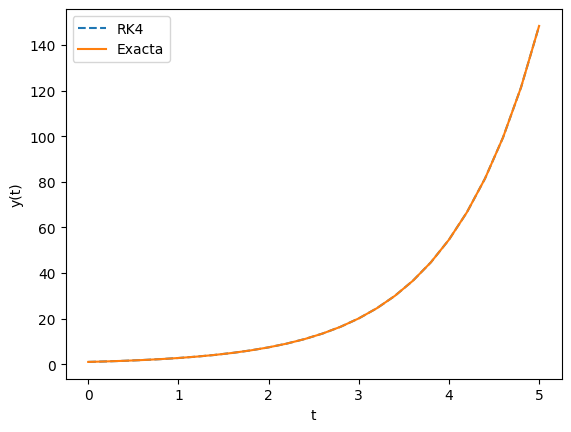

In [19]:
def f(x, y):
  return y

# Condiciones iniciales
t0 = 0
tf = 5
h = 0.2
Y0 = [1.0]  # y(0) = 1

t_RK4, Yn_RK4 = RK4(f, t0, tf, Y0, h)
y_exact = lambda t: np.exp(t)

plt.plot(t_RK4, Yn_RK4[0], '--', label = 'RK4')
plt.plot(t_RK4, y_exact(t_RK4), label = 'Exacta')
plt.legend()
plt.xlabel('t')
plt.ylabel('y(t)')
plt.show()


### Ejemplo

$$y'' + 4y = 0$$

con $y(0) = 1, y'(0) = 0$ para $t\in [0, 10]$

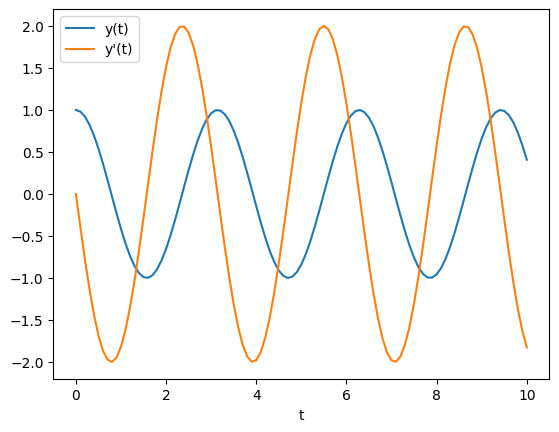

In [20]:
# y'' + 4y = 0  →  y'' = -4y
# Sistema: Y = [y, y'], entonces f(t, Y) = [y', -4y]

def f(t, Y):
  dYdt = np.zeros_like(Y, dtype= float)
  dYdt[0] = Y[1]
  dYdt[1] = -4*Y[0]
  return dYdt

t0 = 0
tf = 10
h = 0.1
Y0 = [1.0, 0.0]  # y(0) = 1, y'(0) = 0

t, Yn = RK4(f, t0, tf, Y0, h)

plt.plot(t, Yn[0], label = 'y(t)')
plt.plot(t, Yn[1], label = "y'(t)")
plt.xlabel('t')
plt.legend()
plt.show()

## Comparación del Error

In [21]:
def Euler(f, t0, tf, Y0, h):
    """
    Integra un sistema de EDO de cualquier orden usando el método de Euler explícito.

    Args:
        f (callable): función f(t, Y) que devuelve dY/dt como array de dimensión m.
        t0 (float): tiempo inicial.
        tf (float): tiempo final.
        Y0 (array_like): vector de condiciones iniciales [y0, y0', ..., y0^{(m-1)}].
        h (float): paso de integración.

    Returns:
        t (ndarray): tiempos desde t0 hasta tf con paso h (longitud N+1).
        Yn (ndarray): aproximación de y, y', ..., y^{(m-1)} en cada t, forma (m, N+1).
    """
    nodos = int((tf - t0) / h)                     # número total de pasos
    m = len(Y0)                                    # orden del sistema (número de variables)
    t = np.zeros(nodos + 1)                        # arreglo de tiempos
    Yn = np.zeros((m, nodos + 1))                  # matriz para soluciones (m derivadas)

    t[0] = t0                                      # tiempo inicial
    Yn[:, 0] = Y0                                  # condición inicial

    for k in range(nodos):
        t[k + 1] = t[k] + h                        # avanza al siguiente tiempo
        Yn[:, k + 1] = Yn[:, k] + h * f(t[k], Yn[:, k])  # paso de Euler explícito

    return t, Yn                                   # retorna arreglo de tiempos y soluciones


import numpy as np

def RK2_PuntoMedio(f, t0, tf, Y0, h):
    """
    Integra un sistema de EDO usando el método de Runge-Kutta de segundo orden (punto medio).

    Args:
        f (callable): función f(t, Y) que devuelve dY/dt como array de dimensión m.
        t0 (float): tiempo inicial.
        tf (float): tiempo final.
        Y0 (array_like): vector de condiciones iniciales [y0, y0', ..., y0^{(m-1)}].
        h (float): paso de integración.

    Returns:
        t (ndarray): arreglo de tiempos desde t0 hasta tf, longitud N+1.
        Y (ndarray): matriz de soluciones, forma (m, N+1).
    """
    nodos = int((tf - t0) / h)              # número de pasos
    m = len(Y0)                             # dimensión del sistema
    t = np.zeros(nodos + 1)                 # vector de tiempos
    Y = np.zeros((m, nodos + 1))            # matriz para soluciones

    t[0] = t0                               # tiempo inicial
    Y[:, 0] = Y0                            # condición inicial

    for k in range(nodos):
        t[k + 1] = t[k] + h                 # avanza el tiempo

        k1 = f(t[k], Y[:, k])               # pendiente en el punto inicial
        k2 = f(t[k] + h/2, Y[:, k] + h/2*k1) # pendiente en el punto medio

        Y[:, k + 1] = Y[:, k] + h * k2      # actualización con la pendiente punto medio

    return t, Y                             # retorna tiempos y soluciones

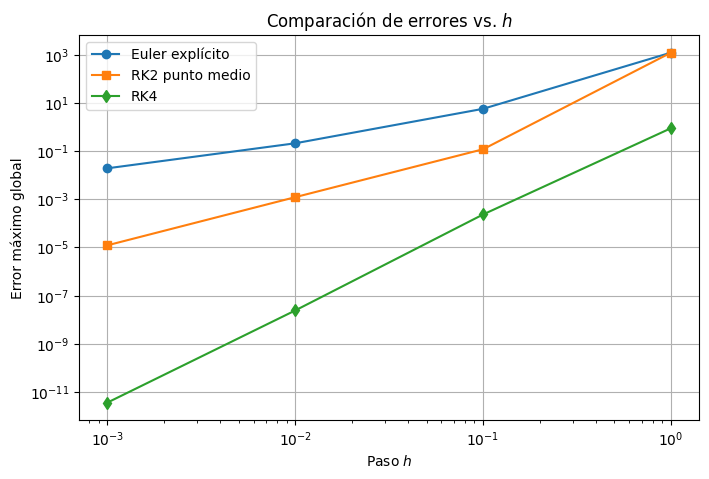

In [22]:
# Solución exacta para comparación
def y_exacta(t):
    return np.cos(2 * t)


# Comparar errores para distintos valores de h
t0, tf = 0, 10
Y0 = [1.0, 0.0]
h_values = np.logspace(-3, 0, 4) # Valores de h para comparar
errors_euler = []
errors_rk2 = []
errors_rk4 = []



for h in h_values:
    # Euler
    t_euler, Y_euler = Euler(f, t0, tf, Y0, h)
    y_exact_interp = y_exacta(t_euler)
    error_euler = np.max(np.abs(Y_euler[0, :] - y_exact_interp))
    errors_euler.append(error_euler)

    # RK2
    t_rk2, Y_rk2 = RK2_PuntoMedio(f, t0, tf, Y0, h)
    y_exact_interp = y_exacta(t_rk2)
    error_rk2 = np.max(np.abs(Y_rk2[0, :] - y_exact_interp))
    errors_rk2.append(error_rk2)

    # RK4
    t_rk4, Y_rk4 = RK4(f, t0, tf, Y0, h)
    y_exact_interp = y_exacta(t_rk4)
    error_rk4 = np.max(np.abs(Y_rk4[0, :] - y_exact_interp))
    errors_rk4.append(error_rk4)

# Gráfico de errores
plt.figure(figsize=(8, 5))
plt.loglog(h_values, errors_euler, 'o-', label='Euler explícito')
plt.loglog(h_values, errors_rk2, 's-', label='RK2 punto medio')
plt.loglog(h_values, errors_rk4, 'd-', label='RK4')
plt.xlabel('Paso $h$')
plt.ylabel('Error máximo global')
plt.title('Comparación de errores vs. $h$')
plt.grid(True)
plt.legend()
plt.show()

## Error y Convergencia en el Método de Runge-Kutta de Orden 4

Su error global es del orden $O(h^4)$, mientras que su error de truncamiento local es del orden $O(h^5)$.

- **Error de truncamiento local:** Se refiere al error cometido en un solo paso de integración y es de orden $O(h^5)$.
- **Error global:** Acumulado a lo largo de la integración y de orden $O(h^4)$.

Esto significa que si el tamaño del paso $h$ se reduce a la mitad, el error global se reduce aproximadamente por un factor de $2^4 = 16$.

## **Convergencia del Método RK4**
El método RK4 es **consistente, estable y convergente**, lo que garantiza que la solución numérica se aproxima a la solución exacta a medida que el tamaño del paso $h \to 0$.

- **Consistencia:** Se satisface porque el error local de truncamiento es $O(h^5)$, lo que implica que el método aproxima correctamente la ecuación diferencial conforme $h$ disminuye.
- **Estabilidad:** Para problemas bien condicionados, el método mantiene una propagación controlada del error, asegurando que la solución numérica no diverja.
- **Convergencia:** Dado que el método es consistente y estable, converge a la solución exacta con una tasa de $O(h^4)$.







## Ejemplo: Orden mayor

Resuelve la ecuación diferencial de tercer orden:  

$$ \frac{d^3y}{dx^3} + 2 \frac{d^2y}{dx^2} + 3 \frac{dy}{dx} + 4y = 0 $$

con las condiciones iniciales:  

$$ y(0) = 1, \quad y'(0) = 0, \quad y''(0) = -1. $$

#### **Conversión a un sistema de primer orden**  

Definimos las siguientes variables:  

$$ y_1 = y, \quad y_2 = \frac{dy}{dx}, \quad y_3 = \frac{d^2y}{dx^2}. $$

De esta forma, la ecuación original se reescribe como el siguiente sistema de ecuaciones de primer orden:  

$$ \frac{dy_1}{dx} = y_2, $$

$$ \frac{dy_2}{dx} = y_3, $$

$$ \frac{dy_3}{dx} = -2y_3 - 3y_2 - 4y_1. $$

Las condiciones iniciales quedan expresadas como:  

$$ y_1(0) = 1, \quad y_2(0) = 0, \quad y_3(0) = -1. $$

In [23]:
def sistema(x, y):
    """
    Sistema de ecuaciones diferenciales de orden 3:
        dy1/dx = y2
        dy2/dx = y3
        dy3/dx = -2*y3 - 3*y2 - 4*y1
    """
    dydt = np.zeros_like(y, dtype= float)  # Crear un vector con la misma forma que y

    dydt[0] = y[1]           # dy1/dx = y2
    dydt[1] = y[2]           # dy2/dx = y3
    dydt[2] = -2*y[2] - 3*y[1] - 4*y[0]  # dy3/dx = -2*y3 - 3*y2 - 4*y1

    return dydt


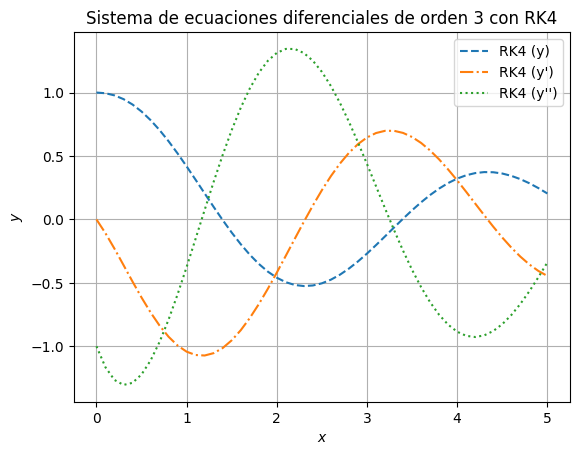

In [24]:
# Condiciones iniciales
x0 = 0
x_end = 5
y0 = np.array([1, 0, -1], dtype = float)  # y1(0) = 1, y2(0) = 0, y3(0) = -1
h = 0.1

x_rk4, y_rk4 = RK4(sistema, x0, x_end, y0, h)

plt.plot(x_rk4, y_rk4[0], '--', label='RK4 (y)')
plt.plot(x_rk4, y_rk4[1], '-.', label='RK4 (y\')')
plt.plot(x_rk4, y_rk4[2], ':', label='RK4 (y\'\')')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.title('Sistema de ecuaciones diferenciales de orden 3 con RK4')
plt.grid(True)
plt.show()


# Resolución de Ecuaciones Diferenciales Ordinarias con `solve_ivp`

La función `scipy.integrate.solve_ivp` [(ver enlace)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) se usa para resolver ecuaciones diferenciales ordinarias (EDO) de primer orden, o sistemas de EDO de orden superior transformados en sistemas de primer orden.

## **Sintaxis básica**
```python
from scipy.integrate import solve_ivp

sol = solve_ivp(func, t_span, y0, method='RK45', t_eval=None)
```

- `func`: Función que define la EDO o sistema de ecuaciones.
- `t_span`: Tupla `(t0, tf)` con el intervalo de integración.
- `y0`: Lista o array con las condiciones iniciales.
- `method`: Método numérico (opcional, ver lista abajo).
- `t_eval`: Puntos específicos en los que evaluar la solución.

## **Métodos disponibles**
- `'RK45'`: Runge-Kutta de orden 4(5) (por defecto).
- `'RK23'`: Runge-Kutta de orden 2(3), más eficiente para problemas rígidos.
- `'Radau'`: Método implícito de Radau (adecuado para problemas rígidos).
- `'BDF'`: Método de diferencias retroactivas (bueno para problemas rígidos).
- `'LSODA'`: Alterna entre métodos explícitos e implícitos según la rigidez.

## **Ejemplo: EDO simple**
Resolver la ecuación:

$$ \frac{dy}{dx} = -2y, \quad y(0) = 1 $$



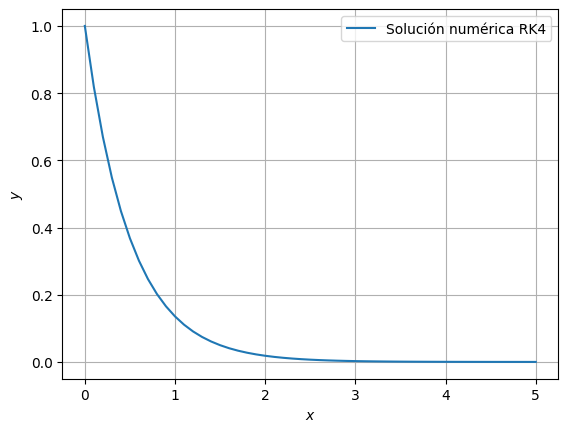

In [25]:
# Definir la función de la EDO
def edo(t, y):
    return -2*y

# Intervalo y condición inicial
t_span = (0, 5)
y0 = [1]
h = 0.1
# Puntos donde evaluar la solución
t = np.arange(0, 5 + h, h)

# Resolver con solve_ivp
sol = solve_ivp(edo, t_span, y0, method='RK45', t_eval=t)

# Graficar la solución
plt.plot(sol.t, sol.y[0], label="Solución numérica RK4")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.grid()
plt.show()

## Ejemplo: Orden mayor

Resuelve la ecuación diferencial de tercer orden:  

$$ \frac{d^3y}{dx^3} + 2 \frac{d^2y}{dx^2} + 3 \frac{dy}{dx} + 4y = 0 $$

con las condiciones iniciales:  

$$ y(0) = 1, \quad y'(0) = 0, \quad y''(0) = -1. $$

#### **Conversión a un sistema de primer orden**  

Definimos las siguientes variables:  

$$ y_1 = y, \quad y_2 = \frac{dy}{dx}, \quad y_3 = \frac{d^2y}{dx^2}. $$

De esta forma, la ecuación original se reescribe como el siguiente sistema de ecuaciones de primer orden:  

$$ \frac{dy_1}{dx} = y_2, $$

$$ \frac{dy_2}{dx} = y_3, $$

$$ \frac{dy_3}{dx} = -2y_3 - 3y_2 - 4y_1. $$

Las condiciones iniciales quedan expresadas como:  

$$ y_1(0) = 1, \quad y_2(0) = 0, \quad y_3(0) = -1. $$



In [26]:
def edo(t, Y):
  '''
  Cambio de variables: y1 = y, y2 = y', y3 = y''
  dy1/dx = y2
  dy2/dx = y3
  dy3/dx = -2y3 - 3y2 - 4y1
  '''
  y1, y2, y3 = Y
  dy1 = y2
  dy2 = y3
  dy3 = -2*y3 - 3*y2 - 4*y1
  return np.array([dy1, dy2, dy3])


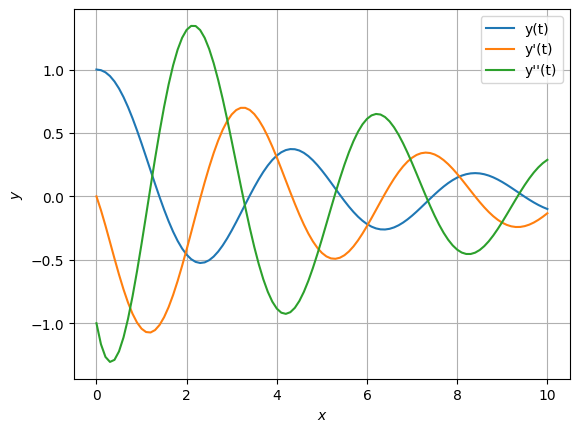

In [27]:
t_span = (0, 10)
y0 = [1, 0, -1]  # Condición inicial para el sistema de orden 3
h = 0.1
# Puntos donde evaluar la solución
t = np.arange(0, 10 + h, h)

# Resolver con solve_ivp
sol = solve_ivp(edo, t_span, y0, method='RK45', t_eval=t)

# Graficar la solución
plt.plot(sol.t, sol.y[0], label='y(t)')
plt.plot(sol.t, sol.y[1], label="y'(t)")
plt.plot(sol.t, sol.y[2], label="y''(t)")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.grid()
plt.show()